In [1]:
import os
import rasterio
from rasterio.plot import plotting_extent
import rioxarray as rxr
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from rasterio.warp import reproject, Resampling
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import geopandas as gpd
from osgeo import gdal
gdal.UseExceptions()
import importlib
import model_comparison_functions
importlib.reload(model_comparison_functions)
from model_comparison_functions import process_all_dates, get_raw_data



In [2]:
task1_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)
task1 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)


In [3]:
stats = []

for key in task1.keys():
    rasters = task1[key]['lidar_clip']
    
    for model, raster in rasters.items():
        ds = rxr.open_rasterio(raster, masked=True).squeeze()
            
        if 'LiDAR' in os.path.basename(raster):
            ds = ds.where(ds < 5)
        else:
            ds
        
        row = {
            "Date": key,
            "Model": model,
            "min": ds.min().values,
            "max": ds.max().values,
            "std": ds.std().values
        }
        
        stats.append(row)
                
    df = pd.DataFrame(stats)
    df.to_csv('T1_summary.csv', index=False)      


In [5]:
stats = []

for key in task2.keys():
    rasters = task2[key]['lidar_clip']
    
    for model, raster in rasters.items():
        ds = rxr.open_rasterio(raster, masked=True).squeeze()
            
        if 'LiDAR' in os.path.basename(raster):
            ds = ds.where(ds < 5)
        else:
            ds
        
        row = {
            "Date": key,
            "Model": model,
            "min": ds.min().values,
            "max": ds.max().values,
            "std": ds.std().values
        }
        
        stats.append(row)
                
    df = pd.DataFrame(stats)
    df.to_csv('T2_summary.csv', index=False)

In [6]:
task1['20230405']['lidar_2000']

'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\LiDAR_2000_MCS_clip.tif'

In [4]:
regressions = []

def rmse_numpy(actual, predicted):
    return np.sqrt(np.mean((predicted - actual) ** 2))

for key in task1.keys():
    lidar_100 = task1[key]['lidar']
    lidar_2000 = task1[key]['lidar_2000']

    lidar_100 = rxr.open_rasterio(lidar_100, masked=True).squeeze()
    lidar_100 = lidar_100.where(lidar_100 < 5)
    lidar_100_flat = lidar_100.values.flatten()

    lidar_2000 = rxr.open_rasterio(lidar_2000, masked=True).squeeze()
    lidar_2000 = lidar_2000.where(lidar_2000 < 5)
    lidar_2000_flat = lidar_2000.values.flatten()

    resample_tasks = {"Task 1": task1[key]['resample'], "Task 2": task2[key]['resample']}


    # 3. Iterate through tasks and models, using the in-memory LiDAR data
    for task_name, resampled_models in resample_tasks.items():
        for model_name, model_path in resampled_models.items():
            # Open the modeled raster
            modeled = rxr.open_rasterio(model_path, masked=True).squeeze()
            modeled_flat = modeled.values.flatten()

            # Assign the correct LiDAR data (already in memory)
            if "HMS" in model_name:
                lidar_flat = lidar_2000_flat
            else:
                lidar_flat = lidar_100_flat

            # Prepare data for regression by removing NaN values
            mask = ~np.isnan(lidar_flat) & ~np.isnan(modeled_flat)
            x_clean = lidar_flat[mask]
            y_clean = modeled_flat[mask]

            # Perform regression if there is data to compare
            if len(x_clean) > 1 and len(y_clean) > 1:
                regression_result = linregress(x_clean, y_clean)
                rmse = rmse_numpy(x_clean, y_clean)

                row = {
                    "Task": task_name,
                    "Conditions": "Data Assimilation" if task_name == "Task 2" else "Baseline",
                    "Date": key,
                    "Model": model_name,
                    "slope": regression_result.slope,
                    "intercept": regression_result.intercept,
                    "rvalue": regression_result.rvalue,
                    "pvalue": regression_result.pvalue,
                    "stderr": regression_result.stderr,
                    "RMSE": rmse
                }
                regressions.append(row)

# 4. Create the final DataFrame and save to CSV
df = pd.DataFrame(regressions)
if 'rvalue' in df.columns:
    df['r-squared'] = df['rvalue']**2
df.to_csv('regression_results.csv', index=False)


In [13]:
df_filtered_isno = df[(df['Model'] == 'iSnobal') | (df['Model'] == 'SnowModel')]
df_filtered_hms = df[(df['Model'] == 'HMS-Energy-Balance') | (df['Model'] == 'HMS-Temperature-Index')]

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_18296\3247053853.py:4: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


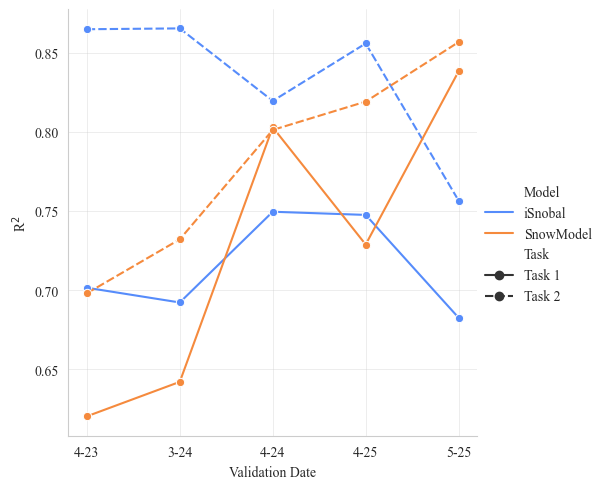

In [14]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

g = sns.relplot(
    data=df_filtered_isno,
    x='Date',
    y='r-squared',
    hue='Model',
    style='Task',
    kind='line',
    markers = 'o')
g.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
g.set_axis_labels("Validation Date", 
                  "R$^2$", 
                  #fontsize=22
                  )
g.tick_params(axis='both', which='major', 
#              labelsize=20
              )
g._legend.set_title("")
# 
# g.fig.suptitle(
#     "Modeled Snow Depth versus LiDAR",
#     #ontsize=22,
#     y=1.05,
#     ha='center',
#     x=0.45
# )

# sns.move_legend(
#     g, "upper left", 
#     bbox_to_anchor=(.8, .75), 
#     title="",           
#     #fontsize=20,       
#     title_fontsize=1    
# )
plt.savefig(
    "C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/iSno_rsquared.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_18296\3671559548.py:4: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


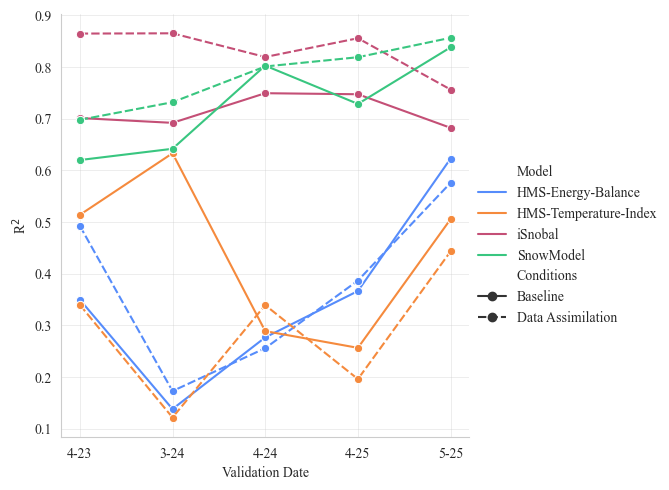

In [15]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

g = sns.relplot(
    data=df,
    x='Date',
    y='r-squared',
    hue='Model',
    style='Conditions',
    kind='line',
    markers = 'o')
g.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
g.set_axis_labels("Validation Date", 
                  "R$^2$", 
                  #fontsize=22
                  )
g.tick_params(axis='both', which='major', 
#              labelsize=20
              )
g._legend.set_title("")
# 
# g.fig.suptitle(
#     "Modeled Snow Depth versus LiDAR",
#     #ontsize=22,
#     y=1.05,
#     ha='center',
#     x=0.45
# )

# sns.move_legend(
#     g, "upper left", 
#     bbox_to_anchor=(.8, .75), 
#     title="",           
#     #fontsize=20,       
#     title_fontsize=1    
# )
plt.savefig(
    "C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/iSno_rsquared.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_18296\2697973192.py:4: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


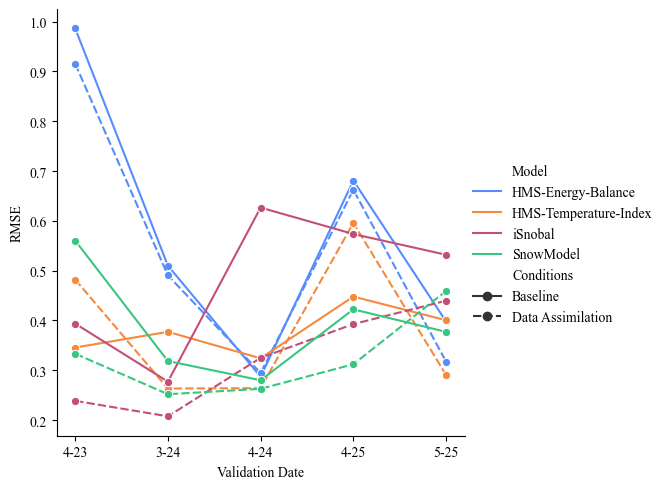

In [6]:
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

g = sns.relplot(
    data=df,
    x='Date',
    y='RMSE',
    hue='Model',
    style='Conditions',
    kind='line',
    markers = 'o')
g.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
g.set_axis_labels("Validation Date", "RMSE", 
                  #fontsize=22
                  # 
                  # 
                  )
g.tick_params(axis='both', which='major', 
              #labelsize=20
              )
#g._legend.set_title("")

# g.fig.suptitle(
#     "Modeled Snow Depth versus LiDAR",
#     fontsize=22,
#     y=1.05,
#     ha='center',
#     x=0.45
# )

# sns.move_legend(
#     g, "upper left", 
#     bbox_to_anchor=(.8, .75), 
#     title="",           
#     fontsize=20,       
#     title_fontsize=1    
# )
plt.savefig(
    "C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/iSno_RMSE.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [1]:
# Assume 'lidar' is defined somewhere in your script as before

def create_regression_plot(YYYYMMDD, plot_title):
    """
    Generates and displays a 4-panel regression plot for snow depth models.

    Args:
        resample_data (dict): A dictionary where keys are model names and values 
                              are paths to the model's raster data.
        plot_date (str): The date string to be used as the main title for the figure.
    """
    sns.set_style('whitegrid')
    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 5), sharey=True)
    fig.suptitle(plot_title, fontsize=18, fontweight='bold')
    
    # --- select data
    date = YYYYMMDD
    lidar = task1[date]['lidar']
    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    resample = task1[date]['resample']

    # --- Loop through each model to create a subplot ---
    for i, (name, model_data_path) in enumerate(resample.items()):
        raster = rxr.open_rasterio(model_data_path, masked=True).squeeze()
        
        # 1. Flatten and clean data
        x = lidar.values.flatten()
        y = raster.values.flatten()
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]

        ax = axs[i]
        
        # 2. Create the regression plot
        sns.regplot(x=x_clean, y=y_clean, ax=ax,
                    scatter_kws={'alpha': 0.8, 's': 10},
                    line_kws={'color': 'red'})
                    
        # 3. Calculate statistics
        slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
        r_squared = r_value**2
        
        # 4. Add titles and labels
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

        # 5. Add statistics text box
        stats_text = f'$R^2 = {r_squared:.3f}$\n$y = {slope:.2f}x + {intercept:.2f}$'
        ax.text(0.05, 0.95, stats_text, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6))

    # --- Final Figure-Level Adjustments ---
    axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
    plt.tight_layout()
    
    # Display the final plot
    plt.show()



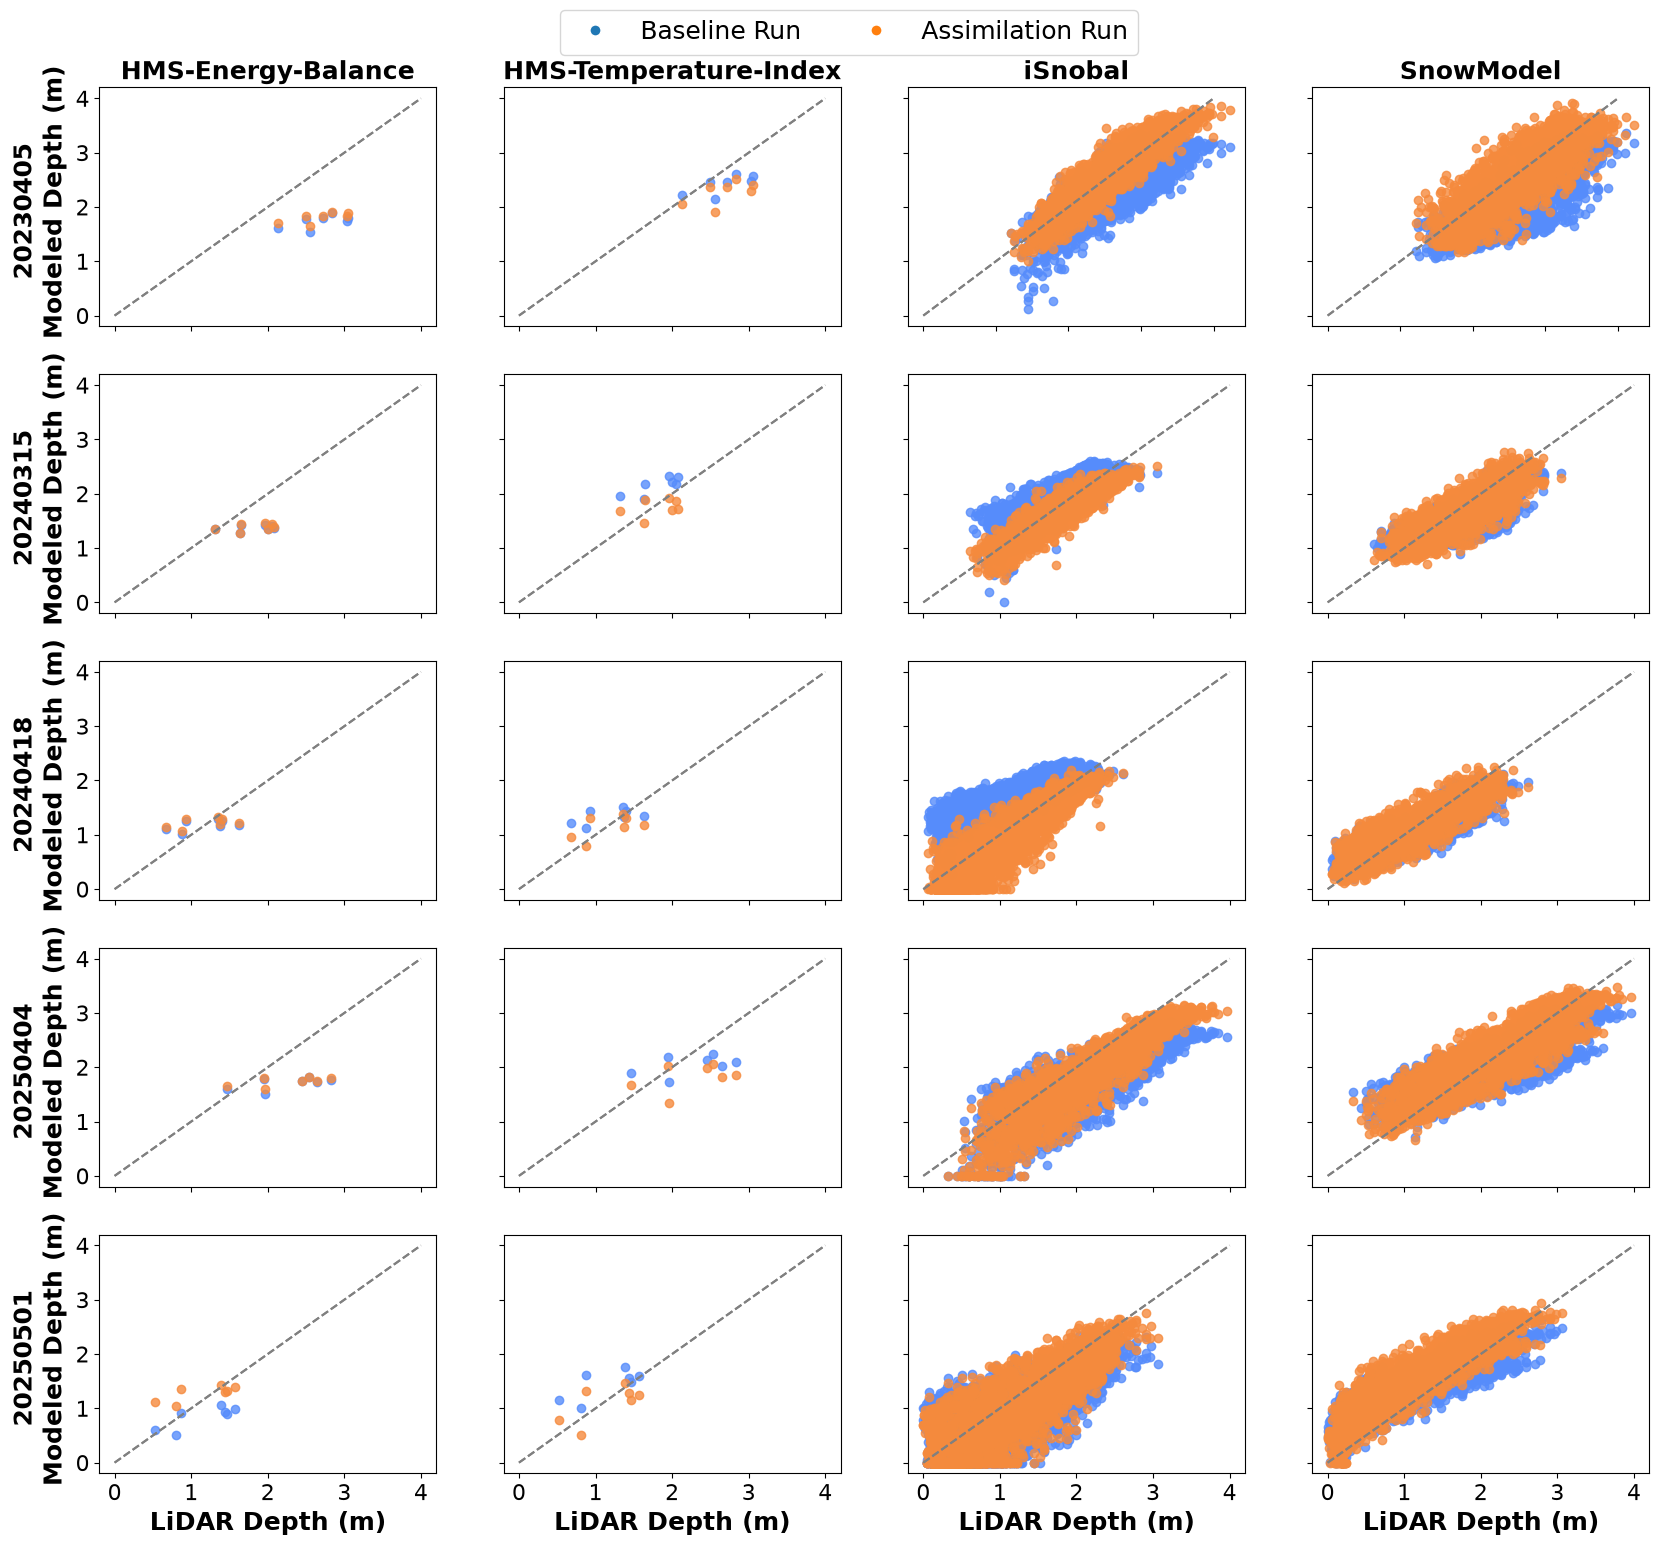

In [5]:
from matplotlib.lines import Line2D


models = [
    "HMS-Energy-Balance",
    "HMS-Temperature-Index",
    "iSnobal",
    "SnowModel"
]

fig, axs = plt.subplots(
    nrows=len(task1),
    ncols=len(models),
    figsize=(20, 18),
    sharey=True
)

for row, date in enumerate(task1.keys()):

    # Load lidar once per date
    lidar_100 = rxr.open_rasterio(
        task1[date]["lidar"],
        masked=True
    ).squeeze()

    lidar_100 = lidar_100.where(lidar_100 < 5)
    lidar_100_flat = lidar_100.values.flatten()

    lidar_2000 = rxr.open_rasterio(
        task1[date]["lidar_2000"],
        masked=True
    ).squeeze()

    lidar_2000 = lidar_2000.where(lidar_2000 < 5)
    lidar_2000_flat = lidar_2000.values.flatten()

    for col, model in enumerate(models):
        ax = axs[row, col]
        ax.tick_params(axis='both', labelsize=16)
        # Choose correct lidar resolution
        if "HMS" in model:
            lidar_flat = lidar_2000_flat
        else:
            lidar_flat = lidar_100_flat

        # ----- Task 1 -----
        model1 = rxr.open_rasterio(
            task1[date]["resample"][model],
            masked=True
        ).squeeze()

        y1 = model1.values.flatten()

        mask1 = np.isfinite(lidar_flat) & np.isfinite(y1)

        sns.regplot(
            x=lidar_flat[mask1],
            y=y1[mask1],
            fit_reg=False,
            ax=ax,
            #scatter_kws={"s": 5, "alpha": 0.3},
            #label="Task 1",
            #color="tab:blue"
        )
        start = [0,0]
        end = [4,4]
        ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')

        # ----- Task 2 -----
        model2 = rxr.open_rasterio(
            task2[date]["resample"][model],
            masked=True
        ).squeeze()

        y2 = model2.values.flatten()

        mask2 = np.isfinite(lidar_flat) & np.isfinite(y2)

        sns.regplot(
            x=lidar_flat[mask2],
            y=y2[mask2],
            ax=ax,
            fit_reg=False
            # scatter_kws={"s": 5, "alpha": 0.3},
            # label="Task 2",
            # color="tab:orange"
        )

        nrows = len(task1)
        if row == nrows - 1:
            ax.set_xlabel("LiDAR Depth (m)",
                          fontweight='bold',
                          fontsize = 18)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x",
                           labelbottom=False)


        if row == 0:
            ax.set_title(model,
                         fontweight='bold',
                         fontsize = 18)

        if col == 0:
            ax.set_ylabel(f"{date} \n Modeled Depth (m)",
                          fontweight='bold',
                          fontsize = 18)

        legend_elements = [
            Line2D([0], [0],
                   marker='o',
                   color='w',
                   label='Baseline Run',
                   markerfacecolor='tab:blue',
                   markersize=8),

            Line2D([0], [0],
                   marker='o',
                   color='w',
                   label='Assimilation Run',
                   markerfacecolor='tab:orange',
                   markersize=8),
        ]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=3,
    fontsize=18,
    bbox_to_anchor=(0.5, .93)
)

plt.savefig(
    "C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/regressions_full.png",
    dpi=300,
    bbox_inches='tight'
)


In [4]:
date = '20230405'

basin_task1 = task1[date]['basin_clip']
HMSEB = basin_task1['HMS-EB']
HMSTI = basin_task1['HMS-TI']
iSnobal = basin_task1['iSnobal']
SnowModel = basin_task1['SnowModel']

raster_list = {'HMS-EB': HMSEB,'HMS-TI':HMSTI, 'SnowModel': SnowModel, 'iSnobal': iSnobal}

In [5]:
raster_list

{'HMS-EB': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\HMS_EB_basin_clip.tif',
 'HMS-TI': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\HMS_TI_basin_clip.tif',
 'SnowModel': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\SnowModel_basin_clip.tif',
 'iSnobal': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\iSnobal_basin_clip.tif'}

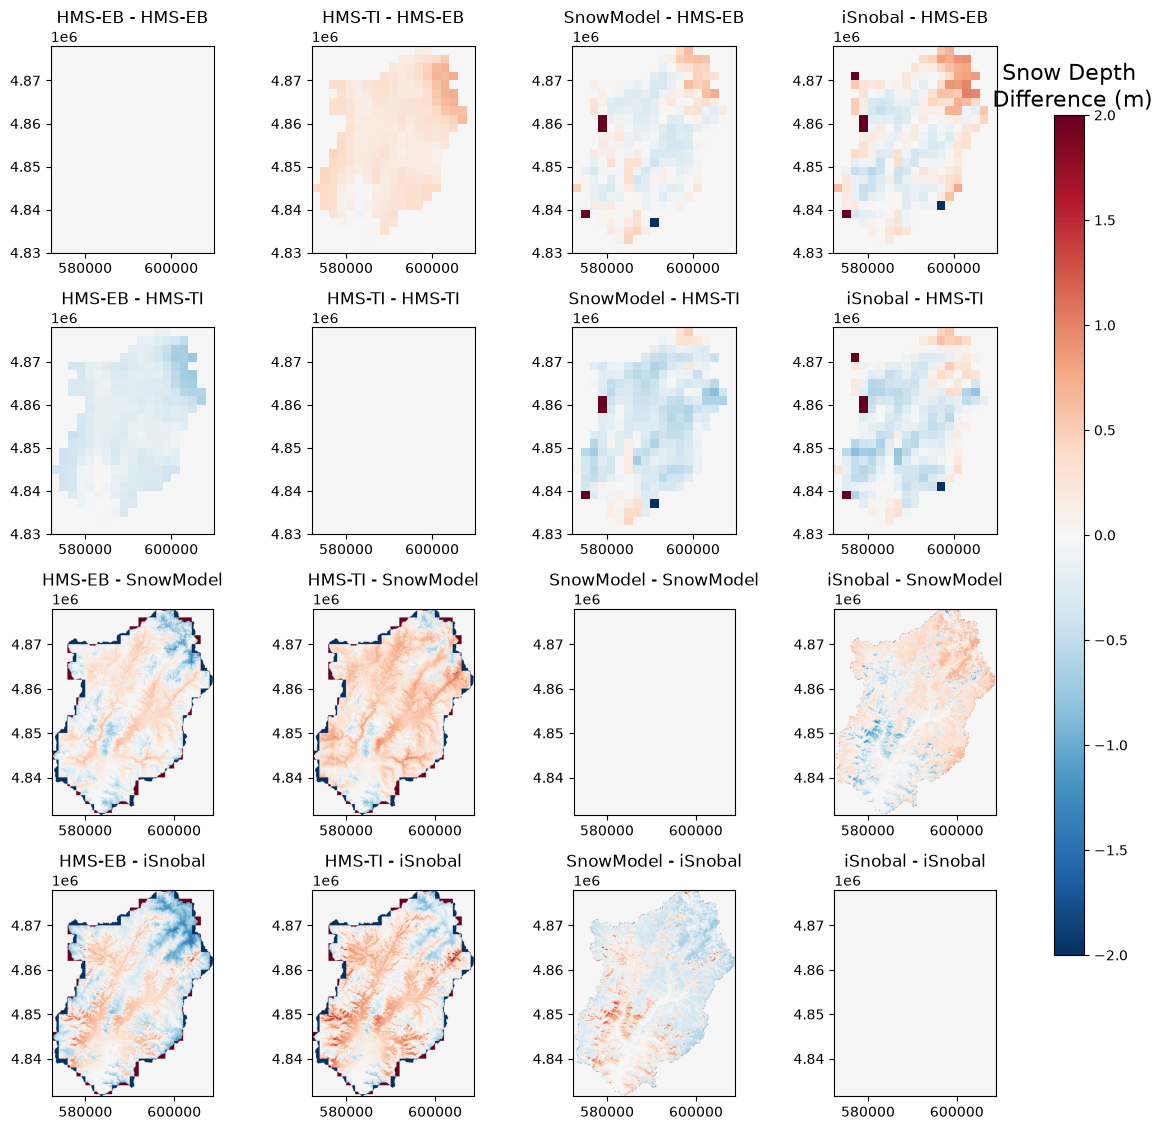

In [8]:

vcenter = 0.0
vmin = -2
vmax = 2
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(12, 12),
                        #sharex=True, sharey=True
            )

for i, (row_model, row_path) in enumerate(raster_list.items()):

    with rasterio.open(row_path) as ref:
        ref_data = ref.read(1)
        extent = plotting_extent(ref)

        for j, (col_model, col_path) in enumerate(raster_list.items()):

            with rasterio.open(col_path) as src:
                src_data = src.read(1)

                reproject_data = np.empty(ref.shape, dtype=src_data.dtype)


                reproject(
                    source=src_data,
                    destination=reproject_data,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=ref.transform,
                    dst_crs=ref.crs,
                    src_nodata=-9999,
                    dst_nodata=-9999,
                    resampling=Resampling.bilinear
                )

                # Column minus row
                diff_array = reproject_data - ref_data

                #print(diff.min(), diff.max())

                ax = axs[i, j]
                im = ax.imshow(diff_array,
                               cmap=colormap,
                               norm=normalize,
                               extent = extent
                               )
                ax.set_title(f"{col_model} - {row_model}")
                ax.grid(False)

fig.tight_layout(rect=[0, 0, 0.9, 0.95]) # Adjust layout to make space
# Add axes for the colorbar [left, bottom, width, height]
cbar_ax = fig.add_axes([0.9, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.set_title('Snow Depth\n Difference (m)', fontsize=16)

plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/basin_compare.png", dpi=600)


In [19]:
print(list(raster_list.keys()))

['HMS-EB', 'HMS-TI', 'SnowModel', 'iSnobal']


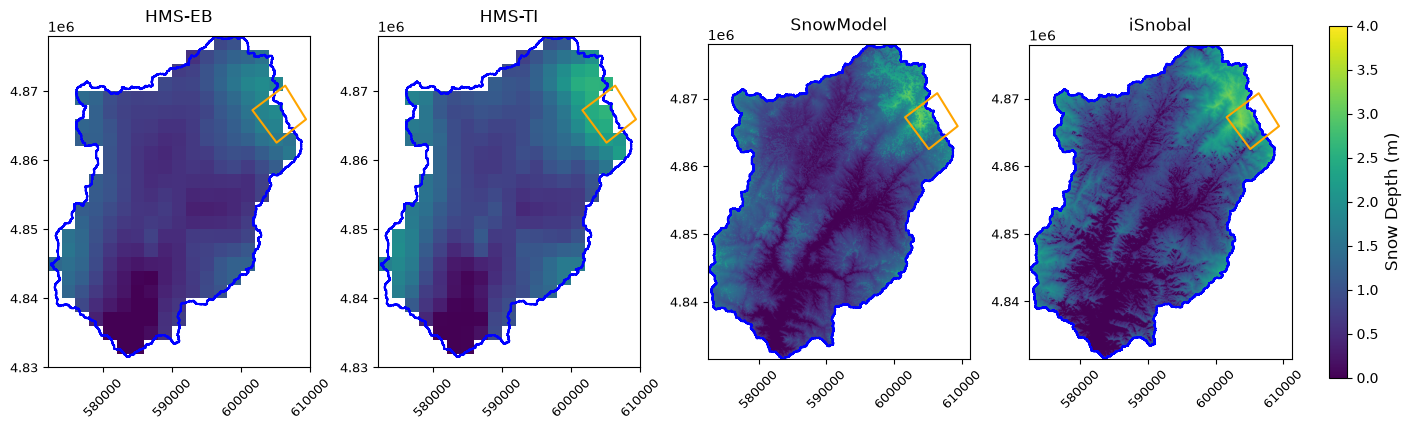

In [13]:

mcs_shp = gpd.read_file(
    "C:/Users/RDCRLSMC/Desktop/GIS/MCS/MCS_shp/MCS_outline.shp"
)

basin_shp = gpd.read_file(
    "C:/Users/RDCRLSMC/Desktop/GIS/basin/basin_outline.shp"
)

fig, axes = plt.subplots(
    1, 4,
    figsize=(14, 4.5),
    constrained_layout=True
)

axes = axes.flatten()

for i, (model, raster) in enumerate(raster_list.items()):

    with rasterio.open(raster) as src:
        data = src.read(1, masked=True)
        extent = plotting_extent(src)

    im = axes[i].imshow(
        data,
        cmap="viridis",
        extent=extent,
        vmin=0,
        vmax=4.0
    )

    # Plot boundaries
    basin_shp.plot(
        ax=axes[i],
        facecolor="none",
        edgecolor="blue",
        linewidth=1.5
    )

    mcs_shp.plot(
        ax=axes[i],
        facecolor="none",
        edgecolor="orange",
        linewidth=1.5
    )

    axes[i].set_title(
        model,
        fontsize=12,
        color="black",
        pad=10
    )

    axes[i].tick_params(
        axis="x",
        rotation=45,
        labelsize=9
    )

    axes[i].tick_params(
        axis="y",
        labelsize=9
    )

    axes[i].grid(False)
    axes[i].set_aspect("equal")


# Add shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.8,
    pad=0.02
)

cbar.set_label(
    "Snow Depth (m)",
    fontsize=12
)

cbar.ax.tick_params(labelsize=10)


plt.savefig(
    "C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/fulls_models_onerow_v2.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

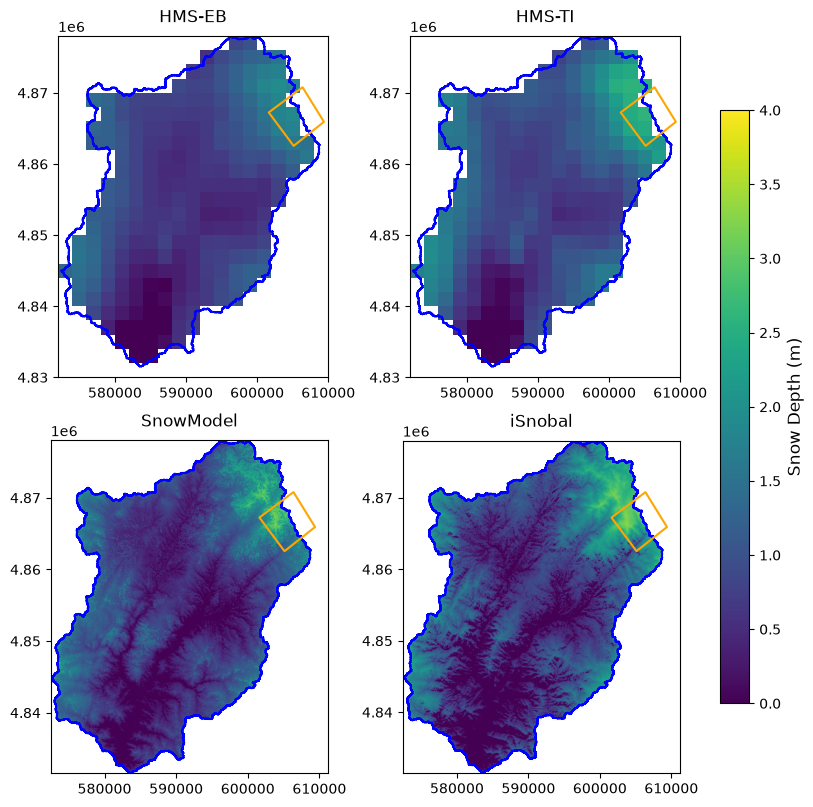

In [12]:

mcs_shp = gpd.read_file(
    "C:/Users/RDCRLSMC/Desktop/GIS/MCS/MCS_shp/MCS_outline.shp"
)

basin_shp = gpd.read_file(
    "C:/Users/RDCRLSMC/Desktop/GIS/basin/basin_outline.shp"
)

fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 8),
    constrained_layout=True
)

axes = axes.flatten()

for i, (model, raster) in enumerate(raster_list.items()):

    with rasterio.open(raster) as src:
        data = src.read(1, masked=True)
        extent = plotting_extent(src)

    im = axes[i].imshow(
        data,
        cmap="viridis",
        extent=extent,
        vmin=0,
        vmax=4.0
    )

    # Plot outlines
    basin_shp.plot(
        ax=axes[i],
        facecolor="none",
        edgecolor="blue",
        linewidth=1.5
    )

    mcs_shp.plot(
        ax=axes[i],
        facecolor="none",
        edgecolor="orange",
        linewidth=1.5
    )

    axes[i].grid(False)
    axes[i].set_aspect("equal")


# Set titles AFTER all plotting
for i, (model, raster) in enumerate(raster_list.items()):
    axes[i].set_title(
        model,
        fontsize=12,
        pad=10
    )


# Add colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.8,
    pad=0.02
)

cbar.set_label(
    "Snow Depth (m)",
    fontsize=12
)


plt.savefig(
    "C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/fulls_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()